# Setup

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
pd.set_option("display.max_columns", None)
 
metrics = pd.read_parquet("../data/raw/train/battery_metrics.parquet")
eol = pd.read_csv("../data/raw/train/eol_times.csv")
devices = pd.read_csv("../data/raw/train/devices.csv")

metrics = metrics.rename(columns={"end_time": "reading_time"})
eol = eol.rename(columns={"end_time": "failure_time"})
devices = devices.rename(columns={"start_time": "deploy_start", "end_time": "window_end"})
 
metrics["reading_time"] = pd.to_datetime(metrics["reading_time"]).dt.tz_localize("UTC")
eol["failure_time"] = pd.to_datetime(eol["failure_time"]).dt.tz_localize("UTC")
devices["deploy_start"] = pd.to_datetime(devices["deploy_start"])
devices["window_end"] = pd.to_datetime(devices["window_end"], format='ISO8601')
 
ID_COL = "device_id"
TIME_COL = "reading_time"
VOLTAGE_COL = "voltage"
TEMP_COL = "temperature"
BUILDING_COL = "building_id"
ROOM_COL = "room_id"

 
print("metrics:", metrics.shape, metrics[ID_COL].nunique(), "unique devices")
print("eol:", eol.shape, eol[ID_COL].nunique(), "unique devices")
print("devices:", devices.shape, devices[ID_COL].nunique(), "unique devices")

metrics: (8520098, 4) 461 unique devices
eol: (461, 2) 461 unique devices
devices: (461, 6) 461 unique devices


In [52]:
# number of unique buildings 
unique_buildings = devices[BUILDING_COL].nunique()
print("Number of unique buildings:", unique_buildings)
print("Number of unique rooms:", devices[ROOM_COL].nunique())
# table of unique buildings with number of rooms and devices in each building
building_summary = devices.groupby(BUILDING_COL).agg(
    num_rooms=(ROOM_COL, 'nunique'),
    num_devices=(ID_COL, 'size')
)
print("Building Summary:")
print(building_summary)

Number of unique buildings: 24
Number of unique rooms: 79
Building Summary:
                num_rooms  num_devices
building_id                           
b_15bc00efc223          2            5
b_2b69c4007582          4           65
b_4217a3b6e58b          4           23
b_53df020ad893          2            6
b_55038c6689a0          1           10
b_60c6d1796ab4          2            5
b_62e09ab003f8          2           33
b_6869b0f15a78          3           11
b_7aac45259c8a          1            4
b_955300d5f090         17          117
b_9a5a45d6e498          4           24
b_a0e6376410cb          6           29
b_ad4a5872f2db          2           17
b_afdd8b1a066d         11           48
b_b57e86051e7e          1            3
b_b7e9d5634ad3          1            4
b_b9acdf6071f3          2            8
b_be0092b8c92e          6           18
b_c2dc4330feb5          1            3
b_c376fc4d6ccb          1            3
b_ce7925d56654          3           16
b_d45195c31e8f          1  

## Build the survival table
 duration = (failure_time if observed, else window_end) - deploy_start
event = 1 if failure_time is not null, else 0 (censored)

In [53]:
surv = eol.merge(
    devices[[ID_COL, "deploy_start", "window_end", BUILDING_COL, "room_id"]],
    on=ID_COL, how="left"
)
 
surv["event"] = surv["failure_time"].notna().astype(int)
surv["end_of_observation"] = surv["failure_time"].fillna(surv["window_end"])
surv["duration_days"] = (surv["end_of_observation"] - surv["deploy_start"]).dt.total_seconds() / 86400
 
print(surv[["device_id", "deploy_start", "failure_time", "window_end", "event", "duration_days"]].head(10))
print(f"\nAny negative durations? {(surv['duration_days'] < 0).sum()}")
print(f"Any missing deploy_start? {surv['deploy_start'].isna().sum()}")

        device_id              deploy_start              failure_time  \
0  d_f44ef99c6628 2023-07-11 11:18:00+00:00                       NaT   
1  d_57e99ff00802 2023-07-11 11:18:00+00:00 2026-02-02 00:00:00+00:00   
2  d_e1772c236402 2023-07-11 11:18:00+00:00                       NaT   
3  d_3703f0819960 2023-07-11 11:18:00+00:00 2025-09-25 00:00:00+00:00   
4  d_2fb7a37dadcd 2023-01-11 17:16:00+00:00                       NaT   
5  d_20b5bd087fd4 2023-03-02 10:30:00+00:00                       NaT   
6  d_dd190a4f9355 2023-03-02 10:30:00+00:00                       NaT   
7  d_2e144a557e02 2023-03-02 10:30:00+00:00                       NaT   
8  d_063c79be3016 2023-03-02 10:30:00+00:00                       NaT   
9  d_b0638b76cb66 2023-03-02 10:30:00+00:00                       NaT   

                        window_end  event  duration_days  
0 2026-08-01 08:56:35.604152+00:00      0    1116.901801  
1 2026-08-01 08:56:35.604152+00:00      1     936.529167  
2 2026-08-01 08:56:

## Q1 — How many sensors, readings per sensor (min/median/max)? Any with too little history?

Unique sensors in battery_metrics: 461
count      461.000000
mean     18481.774403
std       4971.831867
min       7213.000000
25%      14361.000000
50%      18389.000000
75%      21506.000000
max      32093.000000
dtype: float64

Sensors with the fewest readings:
device_id
d_eb7b60348254     7213
d_12deecea69dd     7517
d_eb8be752b2ff     7539
d_98c67d44ad4d     7544
d_4b58677ce660     7587
d_8753828dd859     7587
d_360efda95d1e     7587
d_0d8e1768cb3a     7621
d_be0fde6cb60d     7690
d_3b8706965be3     7730
d_bd045b2e32a2     7996
d_9c81be30f5ac     8347
d_e48beb704ed4     9260
d_7bd1921d0e3c     9995
d_153b5d46b36b    10249
d_dc8f05c852c6    10284
d_a12d4c724c23    10289
d_a95d5d10df5a    10293
d_a98a55fd1547    10367
d_97f334f0b4f5    10509
dtype: int64

Devices in eol_times with NO rows in battery_metrics: 0


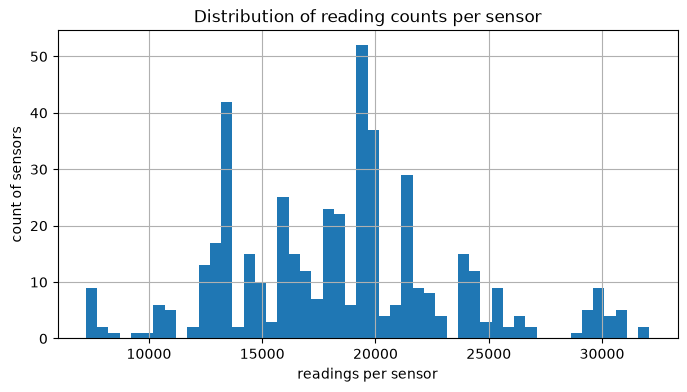

In [54]:
reads_per_sensor = metrics.groupby(ID_COL, observed=True).size()
 
print(f"Unique sensors in battery_metrics: {metrics[ID_COL].nunique()}")
print(reads_per_sensor.describe())
 
low_history = reads_per_sensor.sort_values().head(20)
print("\nSensors with the fewest readings:")
print(low_history)
 
# cross-check: does every device in eol_times/devices actually have metrics rows?
missing_from_metrics = set(eol[ID_COL]) - set(metrics[ID_COL].unique())
print(f"\nDevices in eol_times with NO rows in battery_metrics: {len(missing_from_metrics)}")
 
plt.figure(figsize=(8, 4))
reads_per_sensor.hist(bins=50)
plt.xlabel("readings per sensor")
plt.ylabel("count of sensors")
plt.title("Distribution of reading counts per sensor")
plt.show()

## Q2 — Missing values? Duplicate (device_id, reading_time) rows?

In [55]:
print("Missing values per column (battery_metrics):")
print(metrics.isna().sum())
print(f"\n% rows with any missing: {metrics.isna().any(axis=1).mean():.4%}")
 
dupes = metrics.duplicated(subset=[ID_COL, TIME_COL]).sum()
print(f"\nDuplicate ({ID_COL}, {TIME_COL}) rows: {dupes}")
if dupes > 0:
    dup_mask = metrics.duplicated(subset=[ID_COL, TIME_COL], keep=False)
    print(metrics[dup_mask].sort_values([ID_COL, TIME_COL]).head(10))
 
print("\nMissing values (eol_times, pre-merge):")
print(eol.isna().sum())
print("\nMissing values (devices):")
print(devices.isna().sum())

Missing values per column (battery_metrics):
reading_time    0
voltage         8
temperature     8
device_id       0
dtype: int64

% rows with any missing: 0.0001%

Duplicate (device_id, reading_time) rows: 0

Missing values (eol_times, pre-merge):
device_id         0
failure_time    379
dtype: int64

Missing values (devices):
Unnamed: 0      0
device_id       0
building_id     0
room_id         0
deploy_start    0
window_end      0
dtype: int64


## Q3 — Censoring ratio: % observed deaths vs. % censored?

In [56]:
print(surv["event"].value_counts())
print(surv["event"].value_counts(normalize=True))

event
0    379
1     82
Name: count, dtype: int64
event
0    0.822126
1    0.177874
Name: proportion, dtype: float64


## Q4 — Population Kaplan-Meier curve: sane shape? Median survival time?

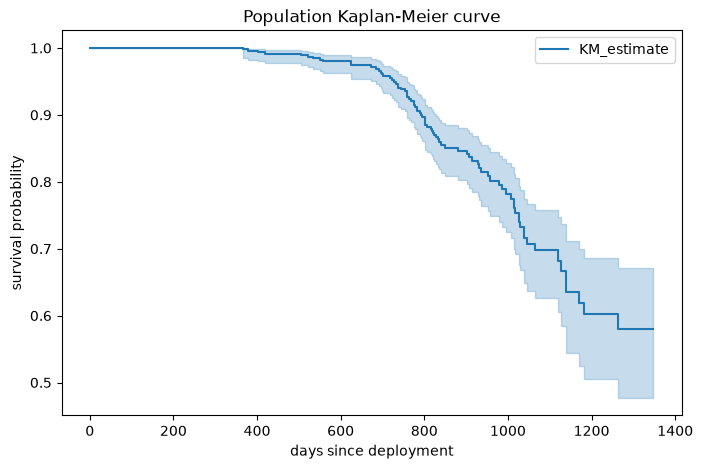

Median survival time (days): inf


In [57]:
from lifelines import KaplanMeierFitter
 
kmf = KaplanMeierFitter()
kmf.fit(surv["duration_days"], event_observed=surv["event"])
 
plt.figure(figsize=(8, 5))
kmf.plot_survival_function()
plt.title("Population Kaplan-Meier curve")
plt.xlabel("days since deployment")
plt.ylabel("survival probability")
plt.show()
 
print(f"Median survival time (days): {kmf.median_survival_time_}")

## Q5 — Do different buildings show visibly different survival curves?

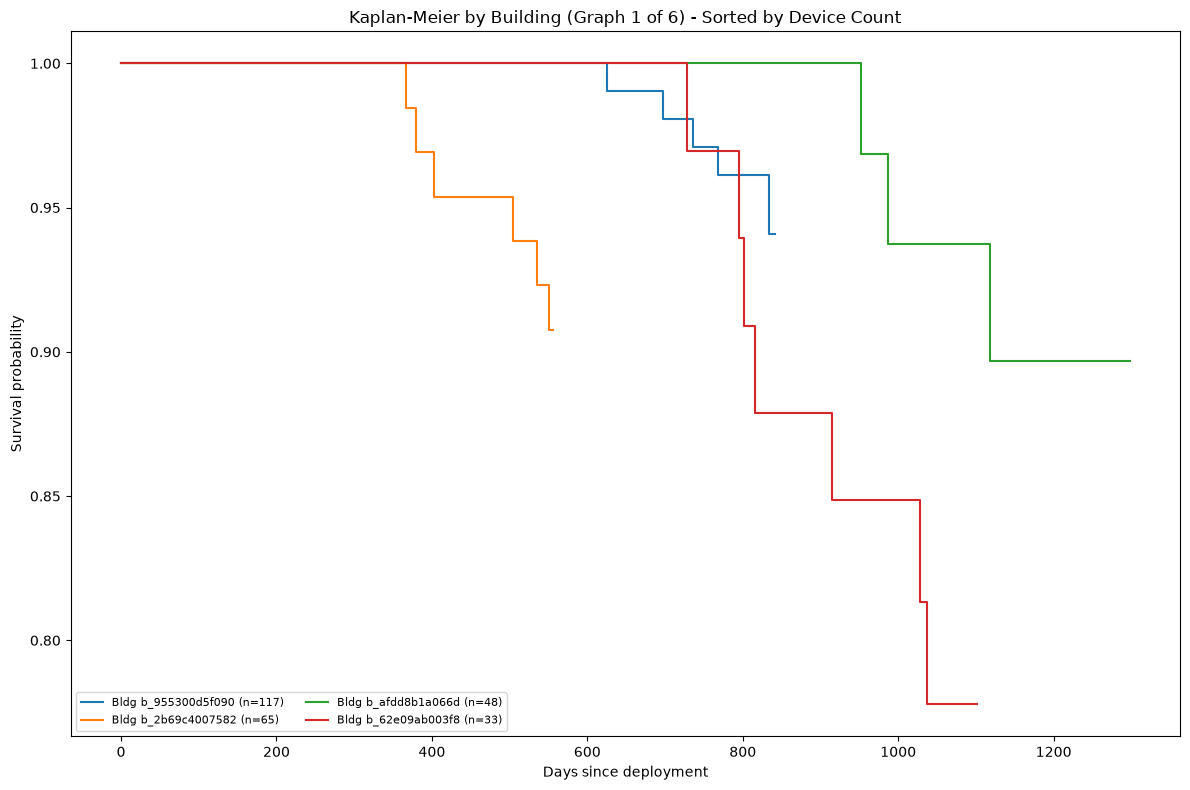

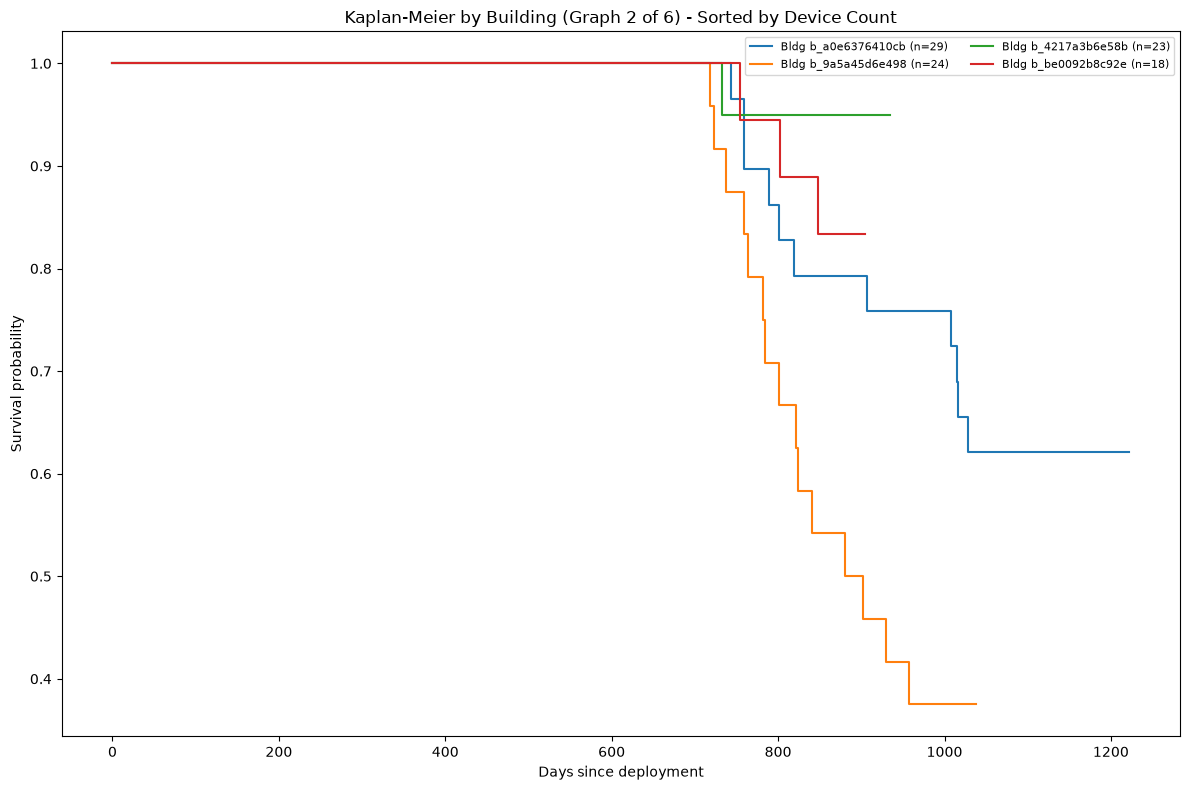

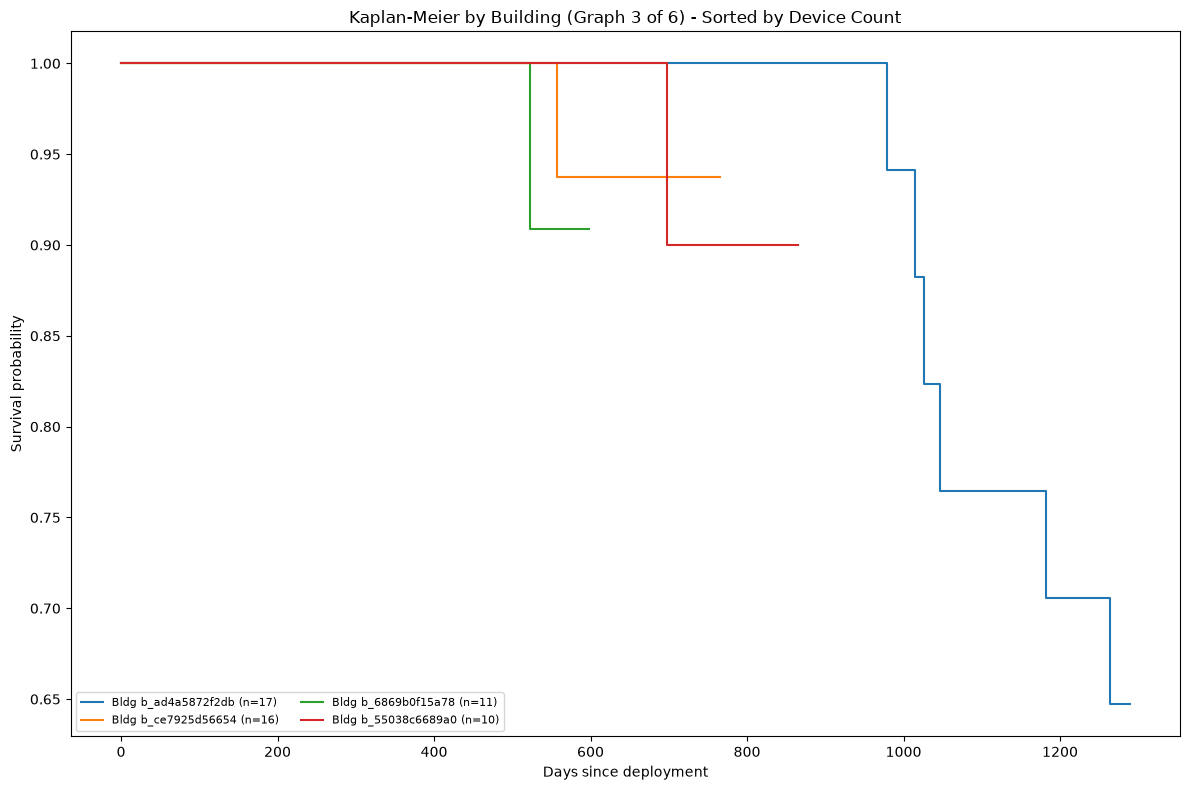

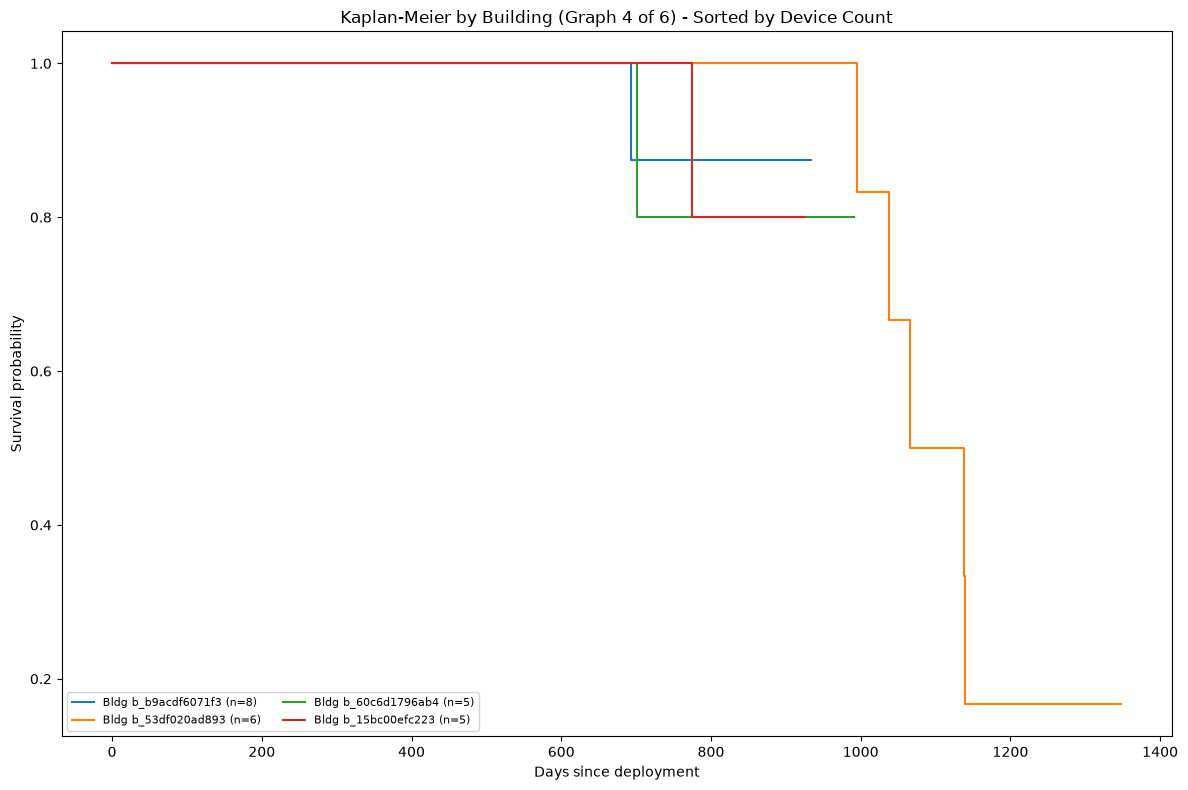

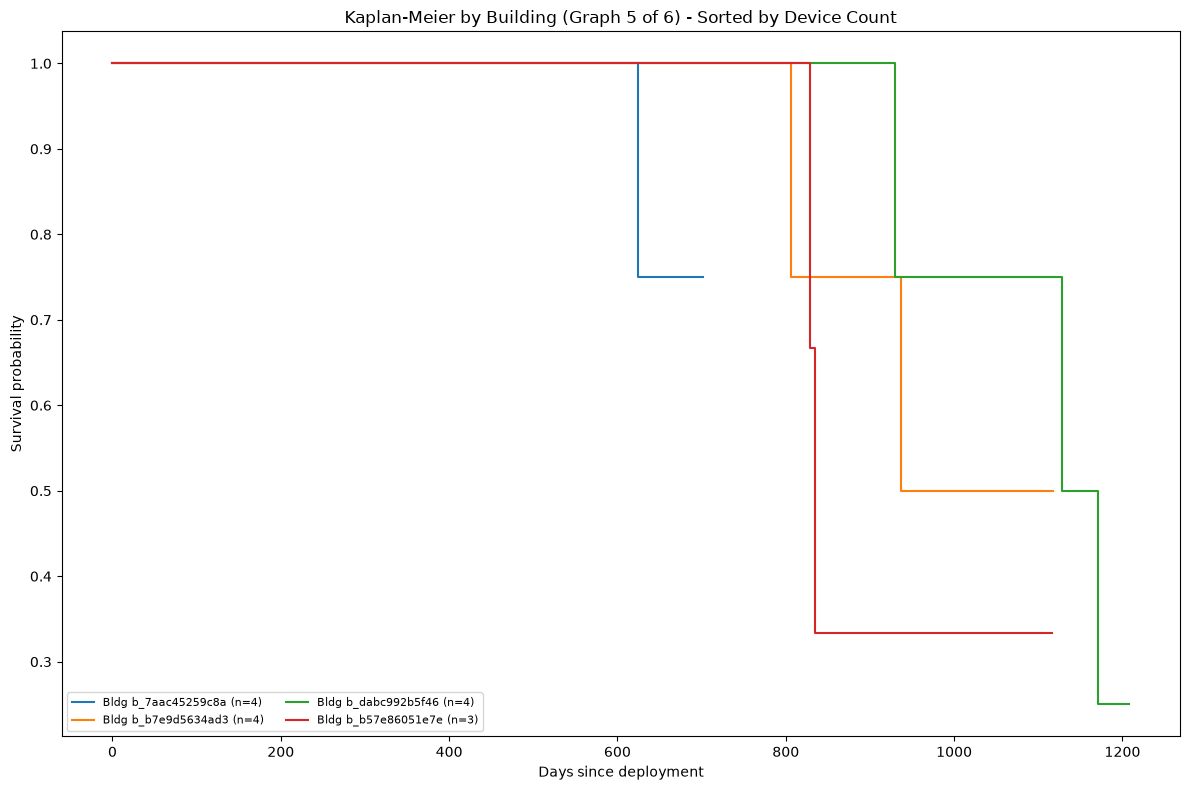

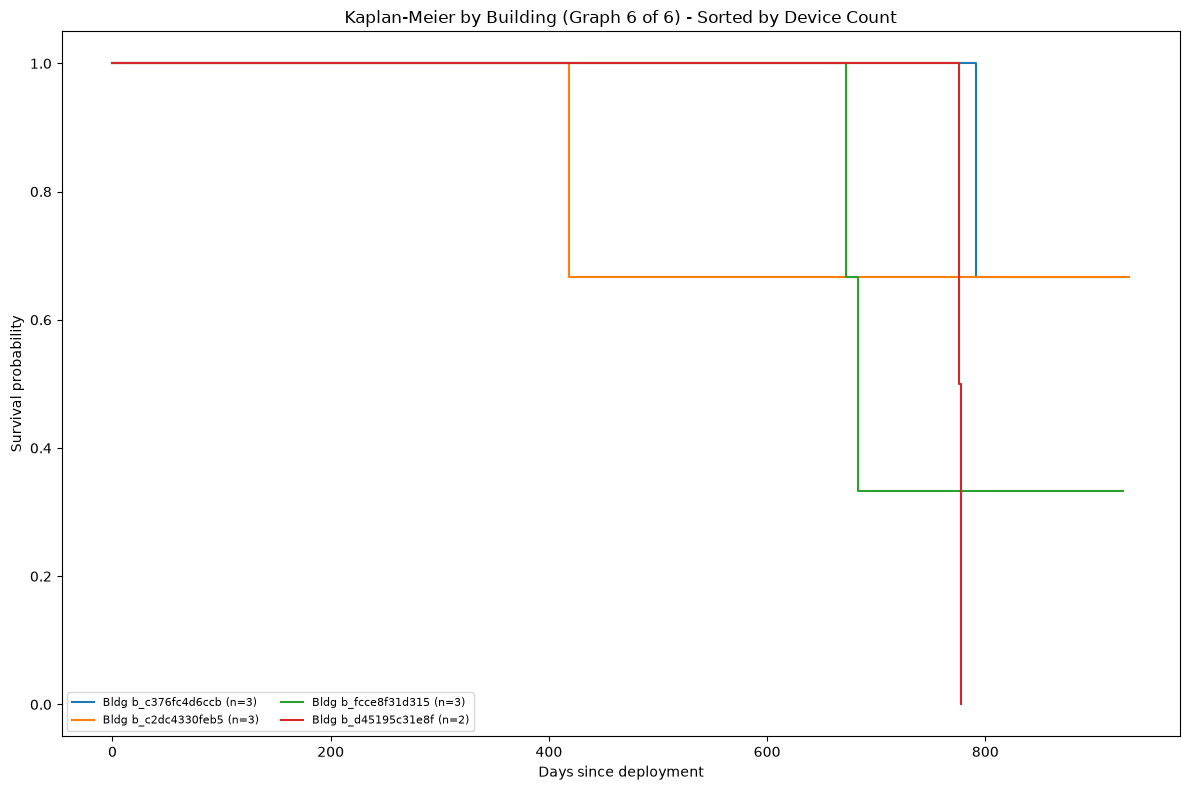

In [58]:
import math

# 1. Count devices per building and sort from LARGEST to smallest
#    This ensures Graph 1 has the best data, Graph 6 has the noisiest data.
building_counts = surv.groupby(BUILDING_COL).size().sort_values(ascending=False)

# 2. Extract the correctly sorted building IDs
sorted_buildings = building_counts.index.tolist()

# 3. Split the sorted list into chunks of exactly 4
chunk_size = 4
building_chunks = [sorted_buildings[i:i + chunk_size] for i in range(0, len(sorted_buildings), chunk_size)]

# 4. Loop through each chunk of 4 and create a separate graph
for chunk_idx, building_subset in enumerate(building_chunks):
    
    # Create a new figure for this chunk of 4 buildings
    plt.figure(figsize=(12, 8))
    ax = plt.subplot(111)
    
    # Loop through the 4 buildings in this specific chunk
    for building in building_subset:
        grp = surv[surv[BUILDING_COL] == building]
        
        # Grab the device count to add context to the legend
        n_devices = building_counts[building]
        
        kmf_b = KaplanMeierFitter()
        kmf_b.fit(
            grp["duration_days"], 
            event_observed=grp["event"], 
            label=f"Bldg {building} (n={n_devices})"  # Shows device count in legend
        )
        kmf_b.plot_survival_function(ax=ax, ci_show=False)
    
    # Add labels and title
    plt.title(f"Kaplan-Meier by Building (Graph {chunk_idx + 1} of 6) - Sorted by Device Count")
    plt.xlabel("Days since deployment")
    plt.ylabel("Survival probability")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

## Q6 — Does voltage visually separate dead vs. still-alive sensors?

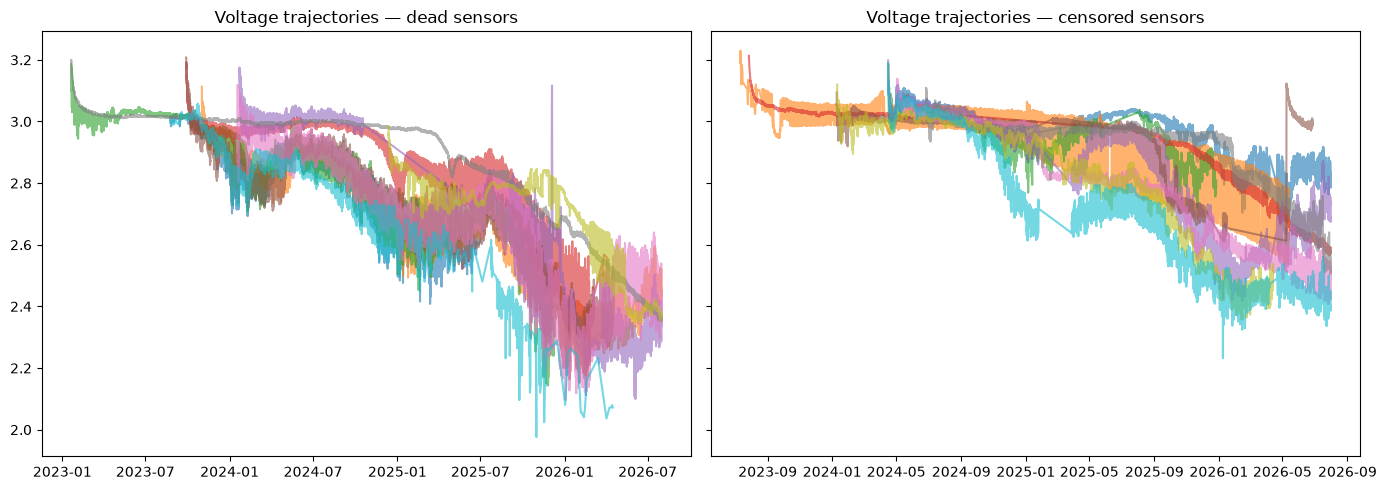

In [59]:
import random 
dead_ids = surv.loc[surv["event"] == 1, ID_COL].tolist()
censored_ids = surv.loc[surv["event"] == 0, ID_COL].tolist()
 
sample_dead = random.sample(dead_ids, min(10, len(dead_ids)))
sample_censored = random.sample(censored_ids, min(10, len(censored_ids)))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
 
for sid in sample_dead:
    d = metrics[metrics[ID_COL] == sid].sort_values(TIME_COL)
    axes[0].plot(d[TIME_COL], d[VOLTAGE_COL], alpha=0.6)
axes[0].set_title("Voltage trajectories — dead sensors")
 
for sid in sample_censored:
    d = metrics[metrics[ID_COL] == sid].sort_values(TIME_COL)
    axes[1].plot(d[TIME_COL], d[VOLTAGE_COL], alpha=0.6)
axes[1].set_title("Voltage trajectories — censored sensors")
 
plt.tight_layout()
plt.show()

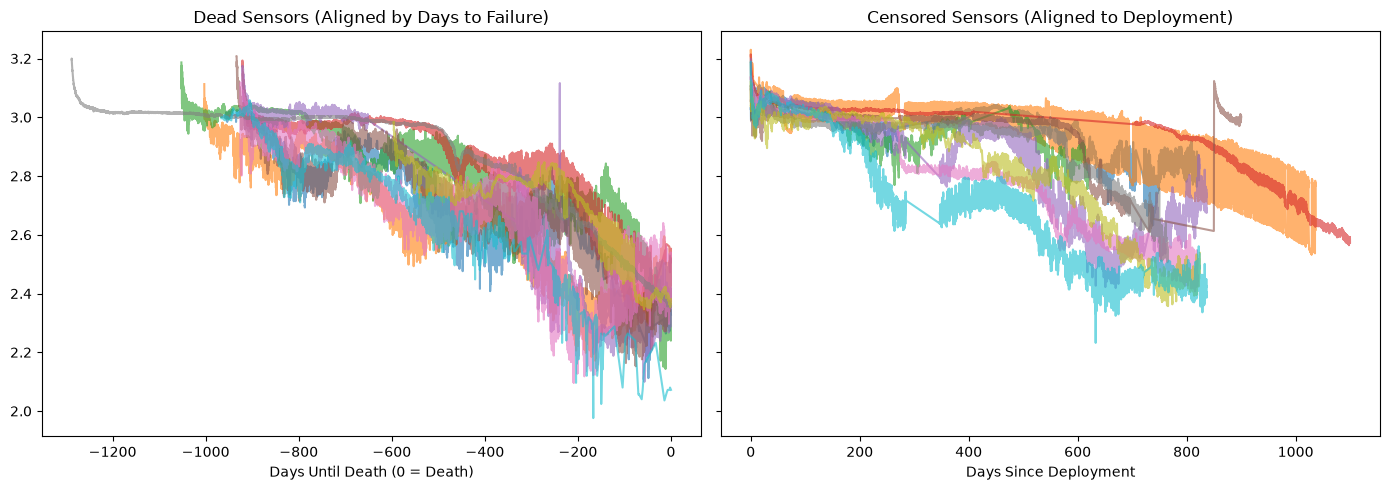

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot Dead Sensors Aligned to End of Life
for sid in sample_dead:
    d = metrics[metrics[ID_COL] == sid].sort_values(TIME_COL).copy()
    
    # Convert dates to 'Days since failure' (0 = moment of failure)
    failure_time = d[TIME_COL].max()
    d["days_to_failure"] = (d[TIME_COL] - failure_time).dt.total_seconds() / 86400
    
    axes[0].plot(d["days_to_failure"], d[VOLTAGE_COL], alpha=0.6)
    
axes[0].set_title("Dead Sensors (Aligned by Days to Failure)")
axes[0].set_xlabel("Days Until Death (0 = Death)")

# Plot Censored Sensors Aligned to Start of Life
for sid in sample_censored:
    d = metrics[metrics[ID_COL] == sid].sort_values(TIME_COL).copy()
    
    # Convert dates to 'Days since deployment' (0 = first reading)
    deploy_time = d[TIME_COL].min()
    d["days_since_deploy"] = (d[TIME_COL] - deploy_time).dt.total_seconds() / 86400
    
    axes[1].plot(d["days_since_deploy"], d[VOLTAGE_COL], alpha=0.6)
    
axes[1].set_title("Censored Sensors (Aligned to Deployment)")
axes[1].set_xlabel("Days Since Deployment")

plt.tight_layout()
plt.show()

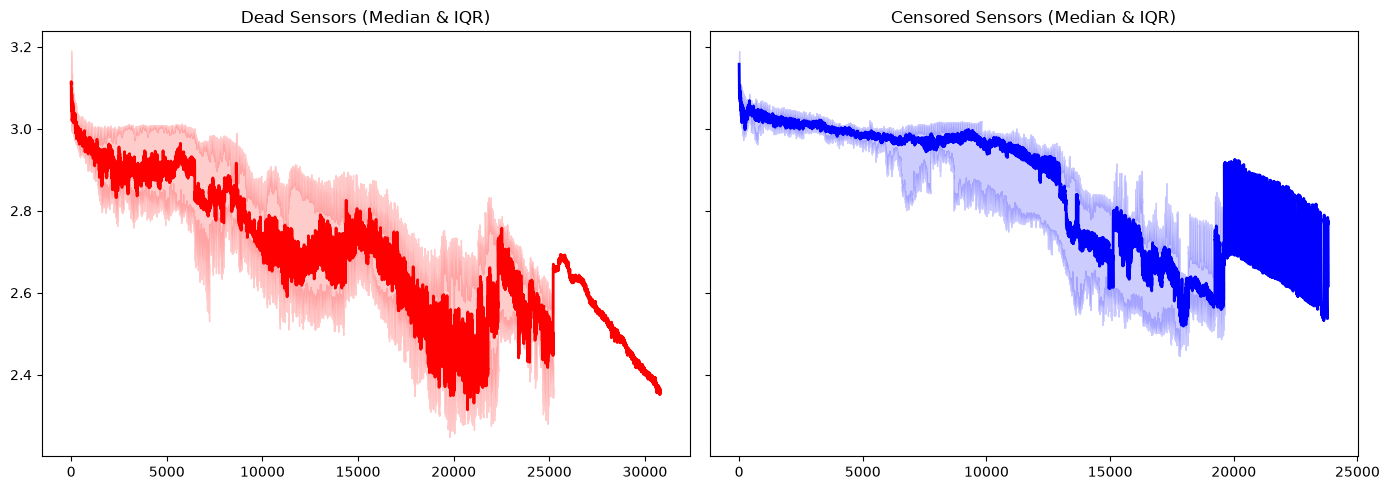

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

def plot_summary(ids, ax, color, title):
    all_dfs = []
    for sid in ids:
        d = metrics[metrics[ID_COL] == sid].sort_values(TIME_COL).copy()
        d["time_rank"] = np.arange(len(d))  # Use rank instead of date
        all_dfs.append(d[["time_rank", VOLTAGE_COL, ID_COL]])
    
    combined = pd.concat(all_dfs)
    # Resample by time_rank to get median and percentiles
    grouped = combined.groupby("time_rank")[VOLTAGE_COL].agg(
        median="median", 
        lower=lambda x: np.percentile(x, 25), 
        upper=lambda x: np.percentile(x, 75)
    )
    
    ax.plot(grouped.index, grouped["median"], color=color, linewidth=2)
    ax.fill_between(grouped.index, grouped["lower"], grouped["upper"], color=color, alpha=0.2)
    ax.set_title(title)

plot_summary(sample_dead, axes[0], "red", "Dead Sensors (Median & IQR)")
plot_summary(sample_censored, axes[1], "blue", "Censored Sensors (Median & IQR)")

plt.tight_layout()
plt.show()

## Q7 — Is pooled voltage-temperature correlation misleading (mixed with time-in-life)?

Pooled voltage-temperature correlation: 0.341


C:\Users\welde\AppData\Local\Temp\ipykernel_42856\2160401210.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_sensor_corr = metrics.groupby(ID_COL, observed=True).apply(



Per-sensor correlation distribution:
count    461.000000
mean       0.273773
std        0.217521
min       -0.385288
25%        0.123665
50%        0.263601
75%        0.419266
max        0.889184
dtype: float64


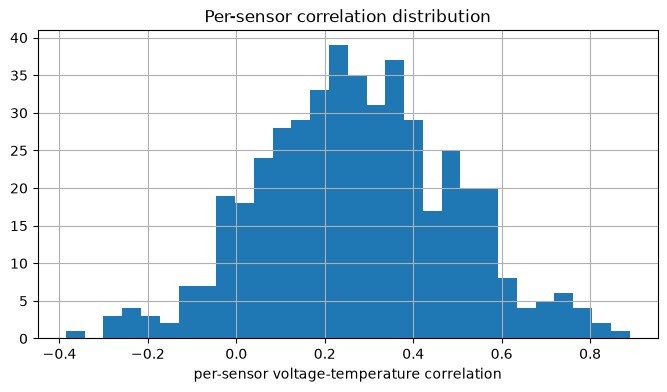

In [62]:
pooled_corr = metrics[[VOLTAGE_COL, TEMP_COL]].corr().iloc[0, 1]
print(f"Pooled voltage-temperature correlation: {pooled_corr:.3f}")
 
per_sensor_corr = metrics.groupby(ID_COL, observed=True).apply(
    lambda d: d[VOLTAGE_COL].corr(d[TEMP_COL]) if len(d) > 5 else np.nan
)
print("\nPer-sensor correlation distribution:")
print(per_sensor_corr.describe())
 
plt.figure(figsize=(8, 4))
per_sensor_corr.hist(bins=30)
plt.xlabel("per-sensor voltage-temperature correlation")
plt.title("Per-sensor correlation distribution")
plt.show()

Pooled voltage-temperature correlation: 0.341


C:\Users\welde\AppData\Local\Temp\ipykernel_42856\1481251247.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_sensor_corr = metrics.groupby(ID_COL, observed=True).apply(



Per-sensor correlation distribution:
count    461.000000
mean       0.273773
std        0.217521
min       -0.385288
25%        0.123665
50%        0.263601
75%        0.419266
max        0.889184
dtype: float64


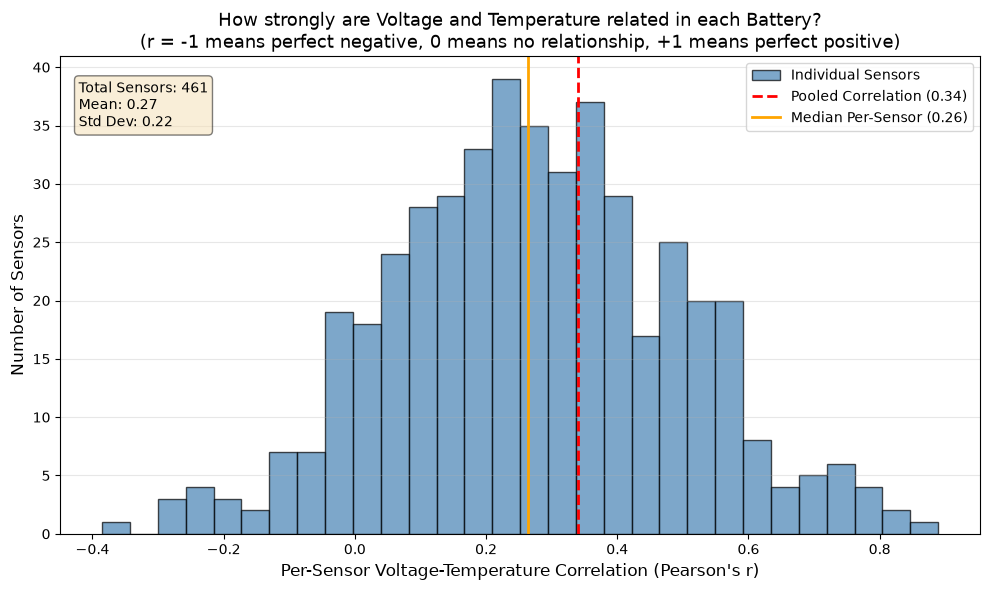

In [63]:
# 1. Keep your original calculations exactly the same
pooled_corr = metrics[[VOLTAGE_COL, TEMP_COL]].corr().iloc[0, 1]
print(f"Pooled voltage-temperature correlation: {pooled_corr:.3f}")

per_sensor_corr = metrics.groupby(ID_COL, observed=True).apply(
    lambda d: d[VOLTAGE_COL].corr(d[TEMP_COL]) if len(d) > 5 else np.nan
)
print("\nPer-sensor correlation distribution:")
print(per_sensor_corr.describe())

# 2. Create a much more descriptive plot
plt.figure(figsize=(10, 6))

# Plot the histogram
n, bins, patches = plt.hist(
    per_sensor_corr, 
    bins=30, 
    color="steelblue", 
    edgecolor="black", 
    alpha=0.7,
    label="Individual Sensors"
)

# Add a vertical line for the "Pooled" (overall) correlation
plt.axvline(
    pooled_corr, 
    color="red", 
    linestyle="--", 
    linewidth=2, 
    label=f"Pooled Correlation ({pooled_corr:.2f})"
)

# Add a vertical line for the Median per-sensor correlation
median_corr = per_sensor_corr.median()
plt.axvline(
    median_corr, 
    color="orange", 
    linestyle="-", 
    linewidth=2, 
    label=f"Median Per-Sensor ({median_corr:.2f})"
)

# 3. Add descriptive labels and title
plt.xlabel("Per-Sensor Voltage-Temperature Correlation (Pearson's r)", fontsize=12)
plt.ylabel("Number of Sensors", fontsize=12)
plt.title(
    "How strongly are Voltage and Temperature related in each Battery?\n"
    "(r = -1 means perfect negative, 0 means no relationship, +1 means perfect positive)",
    fontsize=13
)

# Add a grid for better readability
plt.grid(axis='y', alpha=0.3)

# Add a legend
plt.legend(loc="upper right")

# Add a text box with the key statistics
textstr = f'Total Sensors: {per_sensor_corr.notna().sum()}\nMean: {per_sensor_corr.mean():.2f}\nStd Dev: {per_sensor_corr.std():.2f}'
plt.text(0.02, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

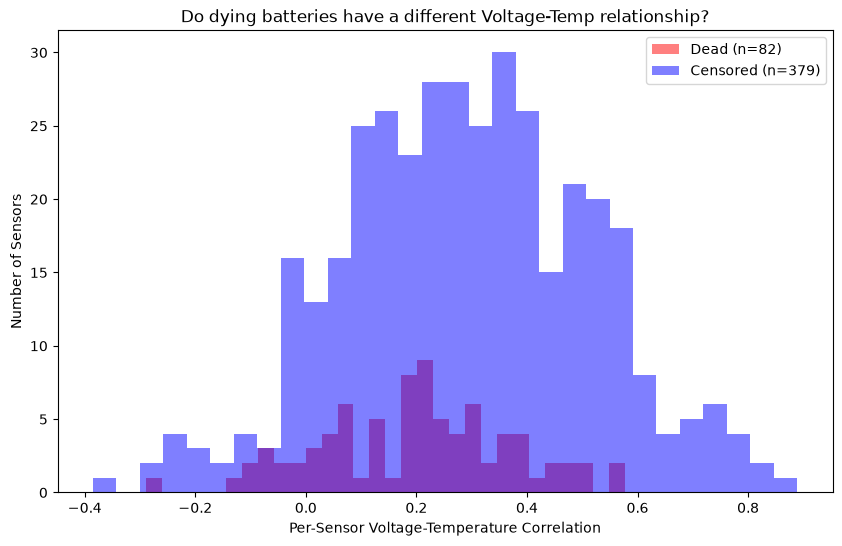

In [30]:
# Quick code to investigate the spread you just found!
# Create a DataFrame from your series
corr_df = per_sensor_corr.reset_index()
corr_df.columns = [ID_COL, 'corr']

# Merge with the survival data (dead vs censored)
corr_df = corr_df.merge(surv[[ID_COL, 'event']], on=ID_COL, how='left')

# Plot overlapping histograms
plt.figure(figsize=(10, 6))
for event_val, label, color in [(1, "Dead", "red"), (0, "Censored", "blue")]:
    subset = corr_df[corr_df['event'] == event_val]['corr'].dropna()
    plt.hist(subset, bins=30, alpha=0.5, color=color, label=f"{label} (n={len(subset)})")

plt.xlabel("Per-Sensor Voltage-Temperature Correlation")
plt.ylabel("Number of Sensors")
plt.title("Do dying batteries have a different Voltage-Temp relationship?")
plt.legend()
plt.show()

## Q8 — Do censoring/event duration distributions look sensible?
(censored durations should skew short — they haven't had time to fail yet)

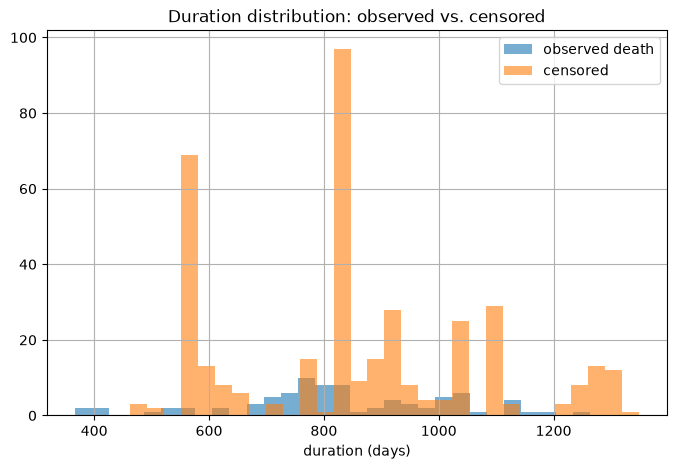

In [64]:
plt.figure(figsize=(8, 5))
surv[surv["event"] == 1]["duration_days"].hist(bins=30, alpha=0.6, label="observed death")
surv[surv["event"] == 0]["duration_days"].hist(bins=30, alpha=0.6, label="censored")
plt.legend()
plt.xlabel("duration (days)")
plt.title("Duration distribution: observed vs. censored")
plt.show()

# how is deployment day distributed

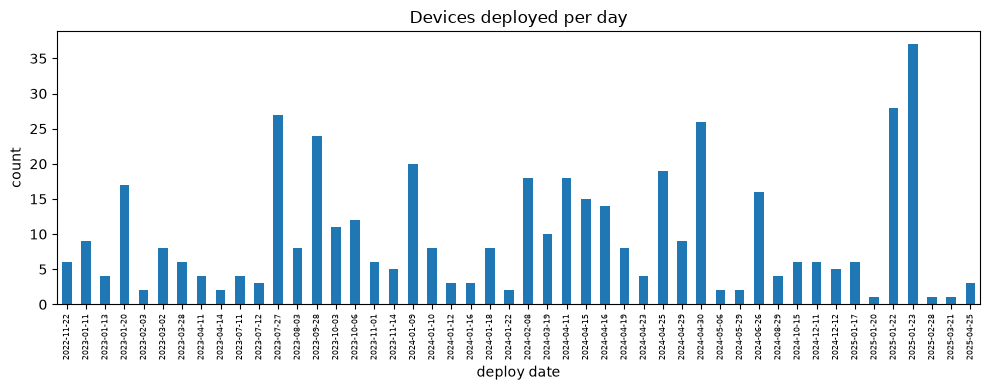

count                                    461
mean     2024-02-21 20:47:03.514099456+00:00
min                2022-11-22 10:57:00+00:00
25%                2023-09-28 11:02:00+00:00
50%                2024-04-11 07:34:00+00:00
75%                2024-05-29 10:12:00+00:00
max                2025-04-25 10:47:00+00:00
Name: deploy_start, dtype: object

Top deployment dates by count:
deploy_start
2025-01-23    37
2025-01-22    28
2023-07-27    27
2024-04-30    26
2023-09-28    24
2024-01-09    20
2024-04-25    19
2024-04-11    18
2024-02-08    18
2023-01-20    17
Name: count, dtype: int64


In [65]:
plt.figure(figsize=(10, 4))
devices["deploy_start"].dt.date.value_counts().sort_index().plot(kind="bar")
plt.title("Devices deployed per day")
plt.xlabel("deploy date")
plt.ylabel("count")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

print(devices["deploy_start"].describe())
print("\nTop deployment dates by count:")
print(devices["deploy_start"].dt.date.value_counts().head(10))

In [66]:
surv["deploy_month"] = surv["deploy_start"].dt.to_period("M")
print(surv.groupby("deploy_month")["event"].agg(["mean", "count"]))

                  mean  count
deploy_month                 
2022-11       0.833333      6
2023-01       0.233333     30
2023-02       0.000000      2
2023-03       0.285714     14
2023-04       0.833333      6
2023-07       0.264706     34
2023-08       0.000000      8
2023-09       0.625000     24
2023-10       0.304348     23
2023-11       0.272727     11
2024-01       0.204545     44
2024-02       0.166667     18
2024-03       0.100000     10
2024-04       0.035398    113
2024-05       0.250000      4
2024-06       0.062500     16
2024-08       0.250000      4
2024-10       0.000000      6
2024-12       0.090909     11
2025-01       0.083333     72
2025-02       0.000000      1
2025-03       0.000000      1
2025-04       0.000000      3


C:\Users\welde\AppData\Local\Temp\ipykernel_42856\3210176564.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  surv["deploy_month"] = surv["deploy_start"].dt.to_period("M")


C:\Users\welde\AppData\Local\Temp\ipykernel_42856\3094357308.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  timeline = pd.date_range(devices["deploy_start"].min(), devices["deploy_start"].max().normalize() + pd.Timedelta(days=1), freq="D")


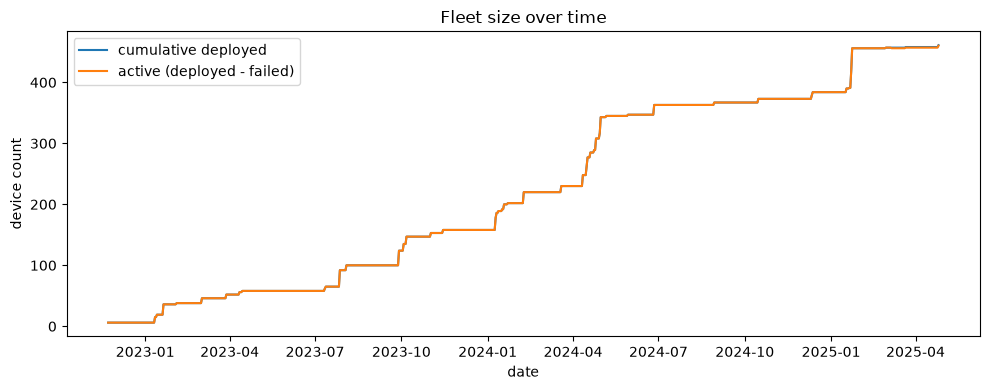

In [67]:
# active count = deployed by then, minus already-failed by then
timeline = pd.date_range(devices["deploy_start"].min(), devices["deploy_start"].max().normalize() + pd.Timedelta(days=1), freq="D")

deployed = devices["deploy_start"].dt.normalize()
failed = surv.loc[surv["event"] == 1, "failure_time"].dt.normalize()

cum_deployed = deployed.value_counts().sort_index().cumsum().reindex(timeline, method="ffill").fillna(0)
cum_failed = failed.value_counts().sort_index().cumsum().reindex(timeline, method="ffill").fillna(0)
active = cum_deployed - cum_failed

plt.figure(figsize=(10, 4))
plt.plot(timeline, cum_deployed, label="cumulative deployed")
plt.plot(timeline, active, label="active (deployed - failed)")
plt.legend()
plt.xlabel("date")
plt.ylabel("device count")
plt.title("Fleet size over time")
plt.tight_layout()
plt.show()

In [68]:
print("Number of unique window_end dates:", devices["window_end"].nunique())
print("Number of unique deploy_start dates:", devices["deploy_start"].nunique())
# table of unique window_end dates with number of devices in each window_end
window_end_summary = devices.groupby("window_end").agg(
    num_devices=("device_id", 'size')
)
print("Window End Summary:")
print(window_end_summary)

Number of unique window_end dates: 5
Number of unique deploy_start dates: 112
Window End Summary:
                                  num_devices
window_end                                   
2025-11-18 09:03:17+00:00                   3
2025-12-26 23:00:00+00:00                  11
2026-02-19 09:56:00+00:00                   1
2026-02-24 11:06:00+00:00                   1
2026-08-01 08:56:35.604152+00:00          445


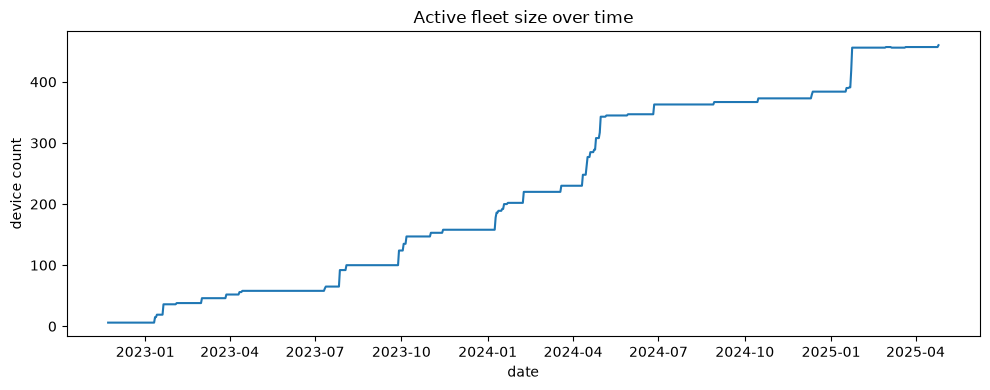

In [69]:
deployed = devices["deploy_start"].dt.normalize()

# exits: death (for observed) or window_end (for censored) — every device exits exactly once
exit_dates = surv["failure_time"].dt.normalize().fillna(
    surv["deploy_start"].map(devices.set_index("device_id")["window_end"]).dt.normalize()
)
# simpler: just merge window_end onto surv directly, you already have it there from the earlier merge
exit_dates = surv.apply(
    lambda r: r["failure_time"].normalize() if r["event"] == 1 else r["window_end"].normalize(),
    axis=1
)

cum_deployed = deployed.value_counts().sort_index().cumsum().reindex(timeline, method="ffill").fillna(0)
cum_exited = exit_dates.value_counts().sort_index().cumsum().reindex(timeline, method="ffill").fillna(0)
active = cum_deployed - cum_exited

plt.figure(figsize=(10, 4))
plt.plot(timeline, active, label="active devices")
plt.xlabel("date")
plt.ylabel("device count")
plt.title("Active fleet size over time")
plt.tight_layout()
plt.show()

window_end value counts:
window_end
2026-08-01 08:56:35.604152+00:00    445
2025-12-26 23:00:00+00:00            11
2025-11-18 09:03:17+00:00             3
2026-02-24 11:06:00+00:00             1
2026-02-19 09:56:00+00:00             1
Name: count, dtype: int64

Earliest window_end (censoring starts affecting the count here): 2025-11-18 00:00:00+00:00

Total devices: 461, total deaths: 82, expected floor after all deaths (before censoring cliff): 379


C:\Users\welde\AppData\Local\Temp\ipykernel_42856\2512678486.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  exit_dates.max() + pd.Timedelta(days=1),


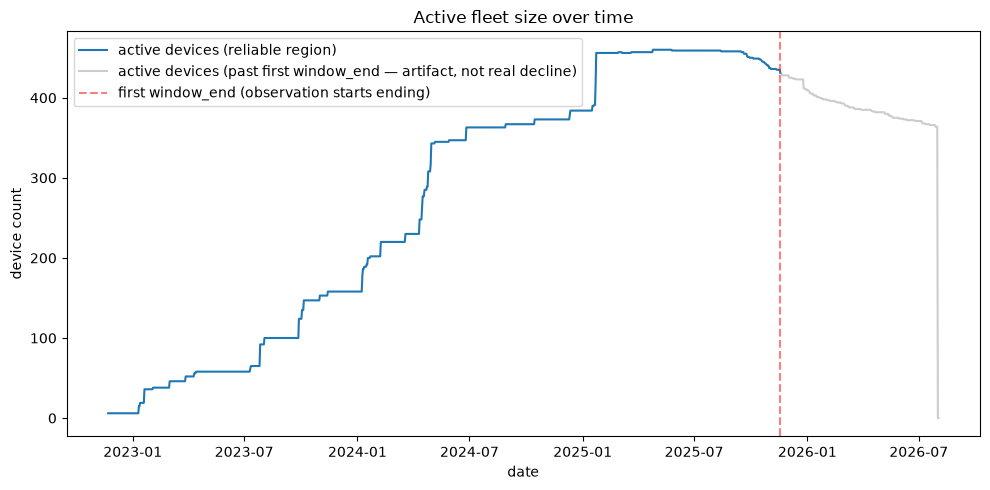

In [70]:

# --- exit date per device: failure_time if observed death, else window_end if censored ---
exit_dates = surv.apply(
    lambda r: r["failure_time"].normalize() if r["event"] == 1 else r["window_end"].normalize(),
    axis=1
)

deployed = devices["deploy_start"].dt.normalize()

# --- check window_end structure before trusting the tail of the plot ---
print("window_end value counts:")
print(devices["window_end"].value_counts())
earliest_window_end = devices["window_end"].min().normalize()
print(f"\nEarliest window_end (censoring starts affecting the count here): {earliest_window_end}")

# --- timeline must cover the FULL exit range, not just deployment range ---
timeline = pd.date_range(
    deployed.min(),
    exit_dates.max() + pd.Timedelta(days=1),
    freq="D"
)

cum_deployed = deployed.value_counts().sort_index().cumsum().reindex(timeline, method="ffill").fillna(0)
cum_exited = exit_dates.value_counts().sort_index().cumsum().reindex(timeline, method="ffill").fillna(0)
active = cum_deployed - cum_exited

# --- sanity check against your manual expectation ---
n_deaths = (surv["event"] == 1).sum()
n_total = len(surv)
print(f"\nTotal devices: {n_total}, total deaths: {n_deaths}, expected floor after all deaths (before censoring cliff): {n_total - n_deaths}")

# --- plot only up to the point where censoring starts distorting the count ---
safe_mask = timeline <= earliest_window_end

plt.figure(figsize=(10, 5))
plt.plot(timeline[safe_mask], active[safe_mask], label="active devices (reliable region)")
plt.plot(timeline[~safe_mask], active[~safe_mask], color="gray", alpha=0.4,
         label="active devices (past first window_end — artifact, not real decline)")
plt.axvline(earliest_window_end, color="red", linestyle="--", alpha=0.5, label="first window_end (observation starts ending)")
plt.legend()
plt.xlabel("date")
plt.ylabel("device count")
plt.title("Active fleet size over time")
plt.tight_layout()
plt.show()

# 2. Build the survival-ready table

## Q2 — Duplicate or missing daily readings

In [71]:
dupe_count = metrics.duplicated(subset=["device_id", "reading_time"]).sum()
print(f"Duplicate (device_id, reading_time) rows: {dupe_count}")

metrics_clean = metrics.drop_duplicates(subset=["device_id", "reading_time"], keep="first").copy()

# completeness = actual readings / expected hourly readings over each device's own span
device_span = metrics_clean.groupby("device_id", observed=True)["reading_time"].agg(["min", "max", "count"])
device_span["expected_hourly_readings"] = (
    (device_span["max"] - device_span["min"]).dt.total_seconds() / 3600
).round().astype(int) + 1
device_span["completeness"] = device_span["count"] / device_span["expected_hourly_readings"]

print("\nCompleteness ratio distribution (1.0 = no gaps):")
print(device_span["completeness"].describe())

low_completeness = device_span[device_span["completeness"] < 0.9].sort_values("completeness")
print(f"\nDevices with <90% completeness: {len(low_completeness)}")
print(low_completeness.head(10))

Duplicate (device_id, reading_time) rows: 0

Completeness ratio distribution (1.0 = no gaps):
count    461.000000
mean       0.923016
std        0.110522
min        0.311106
25%        0.899959
50%        0.984393
75%        0.996303
max        0.998213
Name: completeness, dtype: float64

Devices with <90% completeness: 116
                                     min                       max  count  \
device_id                                                                   
d_eb7b60348254 2023-08-24 04:00:00+00:00 2026-04-16 04:00:00+00:00   7213   
d_bd045b2e32a2 2023-08-24 00:00:00+00:00 2026-04-05 22:00:00+00:00   7996   
d_7bd1921d0e3c 2023-08-24 04:00:00+00:00 2026-06-29 17:00:00+00:00   9995   
d_eb8be752b2ff 2024-04-16 13:00:00+00:00 2025-12-26 23:00:00+00:00   7539   
d_98c67d44ad4d 2024-04-16 13:00:00+00:00 2025-12-26 23:00:00+00:00   7544   
d_3b8706965be3 2024-04-16 13:00:00+00:00 2025-12-26 23:00:00+00:00   7730   
d_497cf69db25f 2024-01-22 09:00:00+00:00 2026-07-31 07:00:

## Q3 — Sensors that died almost immediately (possible defects)

In [72]:
early_deaths = surv[surv["event"] == 1].sort_values("duration_days").head(15)
print("Earliest deaths (candidates for defect/outlier review):")
print(early_deaths[["device_id", "duration_days"]])

# inspect raw trajectories for the earliest few before deciding keep/exclude
for sid in early_deaths["device_id"].head(3):
    d = metrics_clean[metrics_clean["device_id"] == sid].sort_values("reading_time")
    print(f"\n{sid} — {len(d)} readings, voltage range {d['voltage'].min():.2f}-{d['voltage'].max():.2f}")
    print(d[["reading_time", "voltage", "temperature"]].head(5))
    print(d[["reading_time", "voltage", "temperature"]].tail(5))

Earliest deaths (candidates for defect/outlier review):
          device_id  duration_days
423  d_c6e9d12f54f4     366.430556
449  d_30e86d81563a     379.406944
452  d_cbf684280da2     402.406944
322  d_fdcf3fa44b07     418.461806
448  d_766f6b91ee47     504.406944
395  d_80fdf8e269cf     522.565972
441  d_7a18144dbc8c     534.609028
447  d_cf89420c1953     550.406944
376  d_b94797370f49     557.672222
82   d_6a6b1b21a680     624.596528
176  d_d70bb89bb900     625.672917
336  d_9ab87ed4625d     672.534722
337  d_184be698fc36     683.534722
297  d_1a1ecc949d00     692.672222
363  d_9bda8de77e4f     697.541667

d_c6e9d12f54f4 — 13127 readings, voltage range 2.18-3.16
                      reading_time  voltage  temperature
37223125 2025-01-22 14:00:00+00:00   3.1630       19.375
37223126 2025-01-22 15:00:00+00:00   3.0816        6.800
37223127 2025-01-22 16:00:00+00:00   3.0680        6.000
37223128 2025-01-22 17:00:00+00:00   3.0520        5.500
37223129 2025-01-23 04:00:00+00:00   3.05

In [73]:
# %% [markdown]
# ## 2. Build the survival-ready table

# %% [markdown]
# ### Findings from investigation:
# - Reading count: min is 7213 — no sparse-sensor problem, MIN_READINGS filtering not needed.
# - Duplicates: none found in (device_id, reading_time).
# - Completeness: mean 0.92, but ranges down to 0.31 — flagging, not dropping.
# - Early deaths: earliest failure is 366 days in — no defect/outlier concern.

# %%
dupe_count = metrics.duplicated(subset=["device_id", "reading_time"]).sum()
print(f"Duplicate rows: {dupe_count}")  # confirmed 0, but re-checked as safeguard

metrics_clean = metrics.drop_duplicates(subset=["device_id", "reading_time"], keep="first").copy()

device_span = metrics_clean.groupby("device_id", observed=True)["reading_time"].agg(["min", "max", "count"])
device_span["expected_hourly_readings"] = (
    (device_span["max"] - device_span["min"]).dt.total_seconds() / 3600
).round().astype(int) + 1
device_span["completeness"] = device_span["count"] / device_span["expected_hourly_readings"]

# %% [markdown]
# ### Build the one-row-per-sensor table

# %%
COMPLETENESS_FLAG_THRESHOLD = 0.9  # flag only, doesn't exclude anything

survival_table = surv.merge(
    device_span[["min", "max", "count", "completeness"]],
    left_on="device_id", right_index=True, how="left"
).rename(columns={"min": "first_reading", "max": "last_reading", "count": "n_readings"})

survival_table["low_completeness"] = survival_table["completeness"] < COMPLETENESS_FLAG_THRESHOLD

print(f"Final survival table shape: {survival_table.shape}")
print(f"device_id unique? {survival_table['device_id'].is_unique}")
print(f"Devices flagged low_completeness: {survival_table['low_completeness'].sum()} "
      f"({survival_table['low_completeness'].mean():.1%})")

survival_table[["device_id", "duration_days", "event", "n_readings", "completeness", "low_completeness"]].head()

# %% [markdown]
# ### Spot-check (duration, event) against raw data BY HAND

# %%
check_ids = survival_table.sample(5, random_state=42)["device_id"].tolist()

for sid in check_ids:
    row = survival_table[survival_table["device_id"] == sid].iloc[0]
    raw_eol = eol[eol["device_id"] == sid]
    raw_dev = devices[devices["device_id"] == sid]
    print(f"\n--- {sid} ---")
    print(f"deploy_start:   {row['deploy_start']}")
    print(f"failure_time:   {row['failure_time']}")
    print(f"window_end:     {row['window_end']}")
    print(f"-> duration_days: {row['duration_days']:.1f}, event: {row['event']}")
    print(f"raw eol_times row: {raw_eol.to_dict('records')}")
    print(f"raw devices row:   {raw_dev[['deploy_start','window_end']].to_dict('records')}")

Duplicate rows: 0
Final survival table shape: (461, 15)
device_id unique? True
Devices flagged low_completeness: 116 (25.2%)

--- d_0dee527f5202 ---
deploy_start:   2024-04-19 08:49:00+00:00
failure_time:   NaT
window_end:     2026-08-01 08:56:35.604152+00:00
-> duration_days: 834.0, event: 0
raw eol_times row: [{'device_id': 'd_0dee527f5202', 'failure_time': NaT}]
raw devices row:   [{'deploy_start': Timestamp('2024-04-19 08:49:00+0000', tz='UTC'), 'window_end': Timestamp('2026-08-01 08:56:35.604152+0000', tz='UTC')}]

--- d_5b130675e18c ---
deploy_start:   2023-01-11 16:42:00+00:00
failure_time:   NaT
window_end:     2026-08-01 08:56:35.604152+00:00
-> duration_days: 1297.7, event: 0
raw eol_times row: [{'device_id': 'd_5b130675e18c', 'failure_time': NaT}]
raw devices row:   [{'deploy_start': Timestamp('2023-01-11 16:42:00+0000', tz='UTC'), 'window_end': Timestamp('2026-08-01 08:56:35.604152+0000', tz='UTC')}]

--- d_21d63ad64295 ---
deploy_start:   2025-02-28 15:22:00+00:00
failure_

In [74]:
death_check_ids = survival_table[survival_table["event"] == 1].sample(3, random_state=1)["device_id"].tolist()

for sid in death_check_ids:
    row = survival_table[survival_table["device_id"] == sid].iloc[0]
    raw_eol = eol[eol["device_id"] == sid]
    raw_dev = devices[devices["device_id"] == sid]
    print(f"\n--- {sid} ---")
    print(f"deploy_start:   {row['deploy_start']}")
    print(f"failure_time:   {row['failure_time']}")
    print(f"window_end:     {row['window_end']}")
    print(f"-> duration_days: {row['duration_days']:.1f}, event: {row['event']}")
    print(f"raw eol_times row: {raw_eol.to_dict('records')}")


--- d_934319e8a338 ---
deploy_start:   2023-10-06 07:59:00+00:00
failure_time:   2026-01-02 00:00:00+00:00
window_end:     2026-08-01 08:56:35.604152+00:00
-> duration_days: 818.7, event: 1
raw eol_times row: [{'device_id': 'd_934319e8a338', 'failure_time': Timestamp('2026-01-02 00:00:00+0000', tz='UTC')}]

--- d_f57c1450927f ---
deploy_start:   2024-02-08 13:48:00+00:00
failure_time:   2026-04-21 00:00:00+00:00
window_end:     2026-08-01 08:56:35.604152+00:00
-> duration_days: 802.4, event: 1
raw eol_times row: [{'device_id': 'd_f57c1450927f', 'failure_time': Timestamp('2026-04-21 00:00:00+0000', tz='UTC')}]

--- d_7aa40cb4e3a2 ---
deploy_start:   2024-04-30 12:55:00+00:00
failure_time:   2026-05-07 00:00:00+00:00
window_end:     2026-08-01 08:56:35.604152+00:00
-> duration_days: 736.5, event: 1
raw eol_times row: [{'device_id': 'd_7aa40cb4e3a2', 'failure_time': Timestamp('2026-05-07 00:00:00+0000', tz='UTC')}]


# 3. Engineer features

C:\Users\welde\AppData\Local\Temp\ipykernel_42856\256726186.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  cutoff = deploy_start + pd.Timedelta(days=window_days)
C:\Users\welde\AppData\Local\Temp\ipykernel_42856\256726186.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  cutoff = deploy_start + pd.Timedelta(days=window_days)
C:\Users\welde\AppData\Local\Temp\ipykernel_42856\256726186.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  cutoff = deploy_start + pd.Timedelta(days=wi

Feature table: (451, 7), missing device_ids: 10
Final feature_table: (461, 21)
Any NaNs in engineered features? 
voltage_mean     10
voltage_std      10
voltage_slope    10
temp_mean        10
temp_std         10
dtype: int64


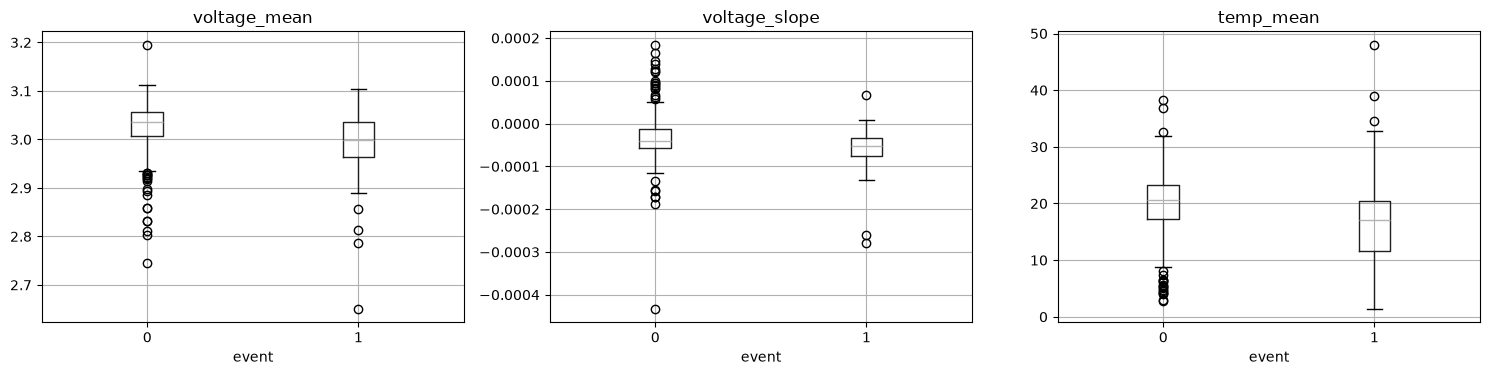

Max reading_time used: 2023-09-09 11:00:00+00:00
Window cutoff:         2023-09-09 11:18:00+00:00
Leakage-free? True


C:\Users\welde\AppData\Local\Temp\ipykernel_42856\256726186.py:72: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  (metrics_clean["reading_time"] < deploy_start + pd.Timedelta(days=WINDOW_DAYS))
C:\Users\welde\AppData\Local\Temp\ipykernel_42856\256726186.py:75: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  print(f"Window cutoff:         {deploy_start + pd.Timedelta(days=WINDOW_DAYS)}")
C:\Users\welde\AppData\Local\Temp\ipykernel_42856\256726186.py:76: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit inst

In [75]:
import numpy as np

# %% [markdown]
# ## 3. Engineer features from the time series (fixed early window, no leakage)

# %%
WINDOW_DAYS = 60  # safe margin under the 366-day minimum survival time

def engineer_device_features(device_id, metrics_df, deploy_start, window_days=WINDOW_DAYS):
    cutoff = deploy_start + pd.Timedelta(days=window_days)
    d = metrics_df[
        (metrics_df["device_id"] == device_id) &
        (metrics_df["reading_time"] >= deploy_start) &
        (metrics_df["reading_time"] < cutoff)
    ].sort_values("reading_time")

    if len(d) < 2:
        return None  # shouldn't happen given the 366-day minimum, but guard anyway

    elapsed_hours = (d["reading_time"] - deploy_start).dt.total_seconds() / 3600
    voltage_slope = np.polyfit(elapsed_hours, d["voltage"], 1)[0]  # per-hour degradation rate

    return pd.Series({
        "n_readings_window": len(d),
        "voltage_mean": d["voltage"].mean(),
        "voltage_std": d["voltage"].std(),
        "voltage_slope": voltage_slope,
        "temp_mean": d["temperature"].mean(),
        "temp_std": d["temperature"].std(),
    })

# build a deploy_start lookup once, avoid re-merging inside the loop
deploy_lookup = survival_table.set_index("device_id")["deploy_start"]

feature_rows = []
for device_id, deploy_start in deploy_lookup.items():
    feats = engineer_device_features(device_id, metrics_clean, deploy_start)
    if feats is not None:
        feats["device_id"] = device_id
        feature_rows.append(feats)

features = pd.DataFrame(feature_rows)
print(f"Feature table: {features.shape}, missing device_ids: {461 - len(features)}")

feature_table = survival_table.merge(features, on="device_id", how="left")
print(f"Final feature_table: {feature_table.shape}")
print(f"Any NaNs in engineered features? \n{feature_table[['voltage_mean','voltage_std','voltage_slope','temp_mean','temp_std']].isna().sum()}")

# %% [markdown]
# ### Sanity check: do these features actually separate dead vs. censored?

# %%
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["voltage_mean", "voltage_slope", "temp_mean"]):
    feature_table.boxplot(column=col, by="event", ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

# %% [markdown]
# ### Leakage check — confirm no reading used past the window cutoff

# %%
# spot-check: max reading_time used per device should never exceed deploy_start + WINDOW_DAYS
check_id = feature_table["device_id"].iloc[0]
deploy_start = deploy_lookup[check_id]
window_reads = metrics_clean[
    (metrics_clean["device_id"] == check_id) &
    (metrics_clean["reading_time"] < deploy_start + pd.Timedelta(days=WINDOW_DAYS))
]
print(f"Max reading_time used: {window_reads['reading_time'].max()}")
print(f"Window cutoff:         {deploy_start + pd.Timedelta(days=WINDOW_DAYS)}")
print(f"Leakage-free? {window_reads['reading_time'].max() < deploy_start + pd.Timedelta(days=WINDOW_DAYS)}")

In [76]:
print(metrics[["voltage", "temperature"]].isna().sum())

bad_rows = metrics[metrics["voltage"].isna() | metrics["temperature"].isna()]
print(bad_rows)

# check if any of these land inside the affected devices' feature windows
for _, row in bad_rows.iterrows():
    sid = row["device_id"]
    if sid in deploy_lookup.index:
        deploy_start = deploy_lookup[sid]
        in_window = deploy_start <= row["reading_time"] < deploy_start + pd.Timedelta(days=WINDOW_DAYS)
        print(f"{sid}: reading_time={row['reading_time']}, in feature window? {in_window}")

voltage        8
temperature    8
dtype: int64
                      reading_time  voltage  temperature       device_id
19890663 2025-12-05 06:00:00+00:00      NaN          NaN  d_751ac25d2ed3
19890664 2025-12-05 07:00:00+00:00      NaN          NaN  d_751ac25d2ed3
30455898 2025-11-26 04:00:00+00:00      NaN          NaN  d_9dd770fbab17
30455899 2025-11-28 06:00:00+00:00      NaN          NaN  d_9dd770fbab17
30455900 2025-11-28 08:00:00+00:00      NaN          NaN  d_9dd770fbab17
19656966 2025-12-05 06:00:00+00:00      NaN          NaN  d_9020559b3e37
19656967 2025-12-05 07:00:00+00:00      NaN          NaN  d_9020559b3e37
19656968 2025-12-05 08:00:00+00:00      NaN          NaN  d_9020559b3e37
d_751ac25d2ed3: reading_time=2025-12-05 06:00:00+00:00, in feature window? False
d_751ac25d2ed3: reading_time=2025-12-05 07:00:00+00:00, in feature window? False
d_9dd770fbab17: reading_time=2025-11-26 04:00:00+00:00, in feature window? False
d_9dd770fbab17: reading_time=2025-11-28 06:00:00+00:0

C:\Users\welde\AppData\Local\Temp\ipykernel_42856\1973022804.py:11: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  in_window = deploy_start <= row["reading_time"] < deploy_start + pd.Timedelta(days=WINDOW_DAYS)


In [77]:
# should have come early in the process but still
metrics_clean = metrics_clean.dropna(subset=["voltage", "temperature"])
print(f"metrics_clean shape after dropping NaN rows: {metrics_clean.shape}")

metrics_clean shape after dropping NaN rows: (8520090, 4)


In [78]:
# Drop the 10 devices that couldn't get windowed features (insufficient readings in first 60 days)
feature_table = feature_table.dropna(subset=["voltage_mean", "voltage_std", "voltage_slope", "temp_mean", "temp_std"]).reset_index(drop=True)

print(f"feature_table after dropping incomplete-feature devices: {feature_table.shape}")
print(f"device_id unique? {feature_table['device_id'].is_unique}")

feature_table after dropping incomplete-feature devices: (451, 21)
device_id unique? True


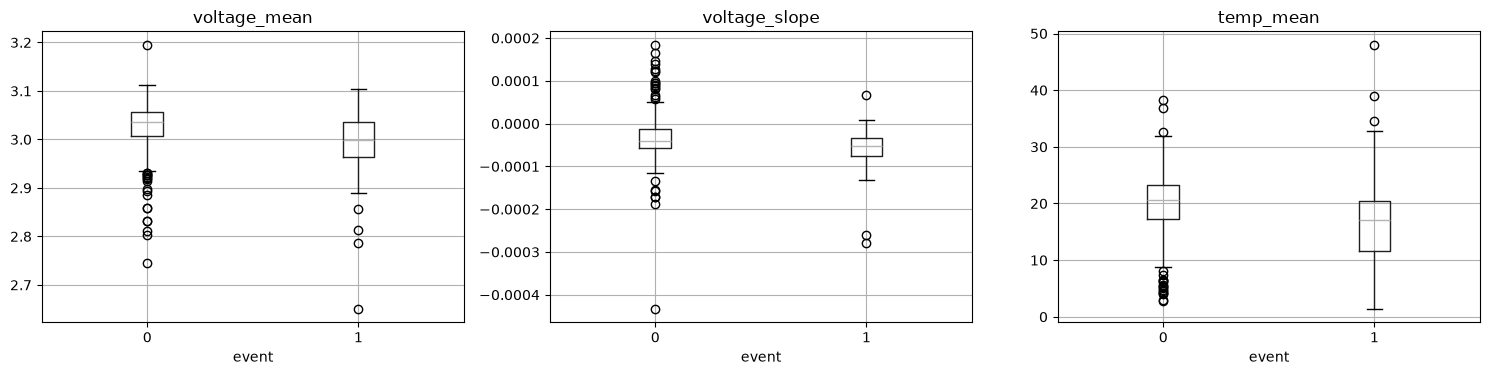

Max reading_time used: 2023-09-09 11:00:00+00:00
Window cutoff:         2023-09-09 11:18:00+00:00
Leakage-free? True


C:\Users\welde\AppData\Local\Temp\ipykernel_42856\1569094073.py:15: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  (metrics_clean["reading_time"] < deploy_start + pd.Timedelta(days=WINDOW_DAYS))
C:\Users\welde\AppData\Local\Temp\ipykernel_42856\1569094073.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  print(f"Window cutoff:         {deploy_start + pd.Timedelta(days=WINDOW_DAYS)}")
C:\Users\welde\AppData\Local\Temp\ipykernel_42856\1569094073.py:19: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit i

In [79]:
# Sanity check: do features separate dead vs. censored?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["voltage_mean", "voltage_slope", "temp_mean"]):
    feature_table.boxplot(column=col, by="event", ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

# Leakage check
check_id = feature_table["device_id"].iloc[0]
deploy_start = deploy_lookup[check_id]
window_reads = metrics_clean[
    (metrics_clean["device_id"] == check_id) &
    (metrics_clean["reading_time"] < deploy_start + pd.Timedelta(days=WINDOW_DAYS))
]
print(f"Max reading_time used: {window_reads['reading_time'].max()}")
print(f"Window cutoff:         {deploy_start + pd.Timedelta(days=WINDOW_DAYS)}")
print(f"Leakage-free? {window_reads['reading_time'].max() < deploy_start + pd.Timedelta(days=WINDOW_DAYS)}")

# 4. basline Cox PH model

Model input shape: (451, 7)
duration_days    0
event            0
voltage_mean     0
voltage_std      0
voltage_slope    0
temp_mean        0
temp_std         0
dtype: int64


c:\Users\welde\Desktop\School\Private_projects\BatterySwapAI\.venv\Lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning: Column(s) ['voltage_slope'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


<lifelines.CoxPHFitter: fitted with 451 total observations, 374 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 451
number of events observed = 77
   partial log-likelihood = -376.65
         time fit was run = 2026-08-18 00:22:22 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
voltage_mean    -11.21      0.00      1.73          -14.61           -7.82                0.00                0.00
voltage_std      -4.05      0.02      8.18          -20.09           11.98                0.00            1.59e+05
voltage_slope -6465.49      0.00   2136.19       -10652.35        -2278.63                0.00                 NaN
temp_mean        -0.03      0.97      0.02           -0.07            0.01                0.93                1.01
temp_std          0.12      1.12      0.07           -0.03            0.26                0.98                1.30

               cmp to     z      p  -log2(p)
covariate                                   
voltage_mean     0.00 -6.48 <0.005     33.32
voltage_std      0.00 -0.50   0.62      0.69
voltage_slope    0.00 -3.03 <0.005      8.66
temp_mean        0.00 -1.34   0.18      2.47
temp_std         0.00  1.62   0.11      3.23
---
Concordance = 0.78
Partial AIC = 763.29
log-likelihood ratio test = 63.64 on 5 df
-log2(p) of ll-ratio test = 38.76


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.
Concordance index: 0.780


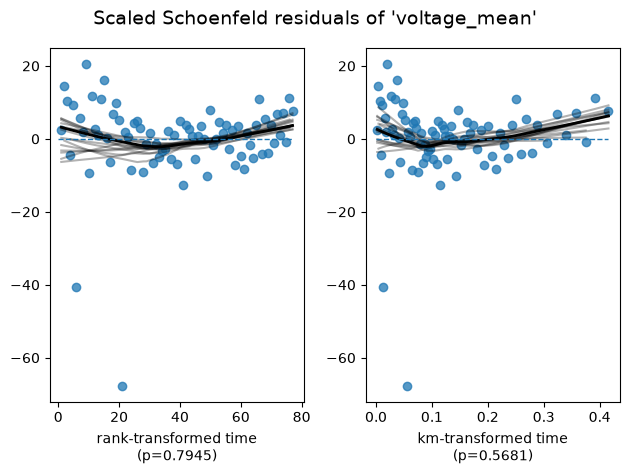

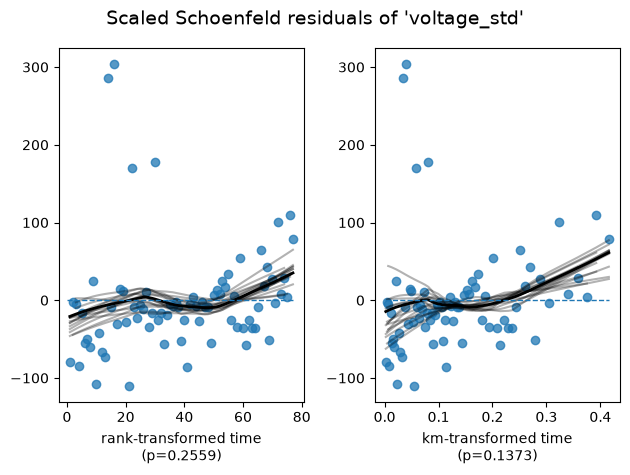

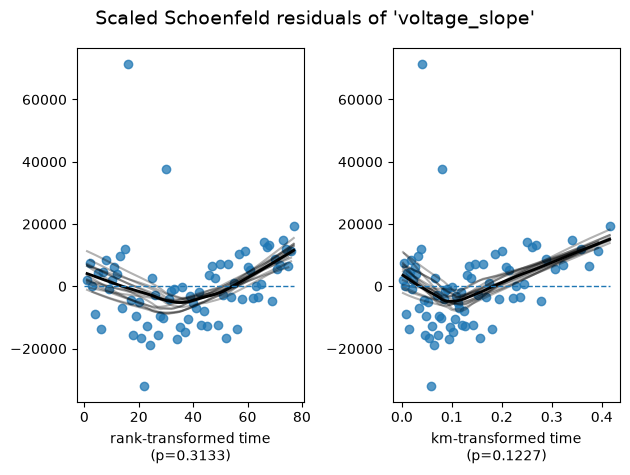

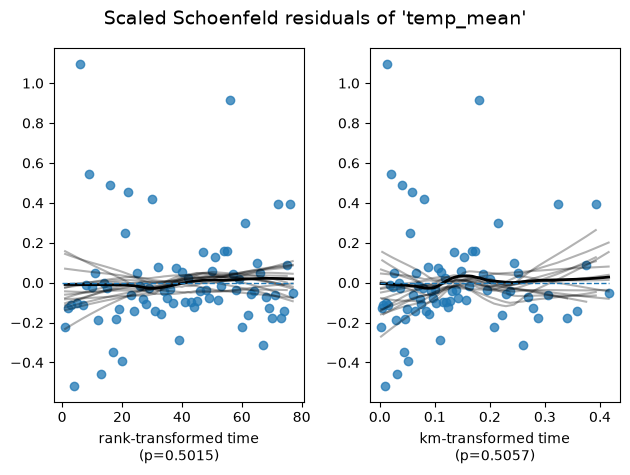

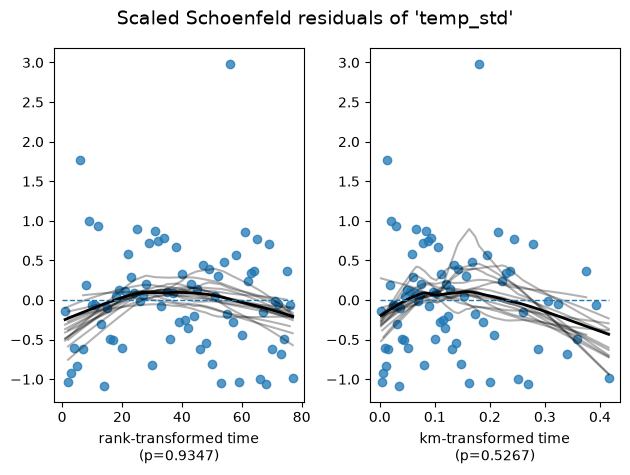

In [80]:
# %% [markdown]
# ## 4. Baseline Cox Proportional Hazards model

# %%
from lifelines import CoxPHFitter

# Select only the columns the model actually needs — duration, event, and covariates.
# Leave out identifiers, raw dates, and QC flags (device_id, building_id, room_id,
# deploy_start, failure_time, window_end, first_reading, last_reading, low_completeness).
model_cols = ["duration_days", "event", "voltage_mean", "voltage_std", "voltage_slope", "temp_mean", "temp_std"]
model_df = feature_table[model_cols].copy()

print(f"Model input shape: {model_df.shape}")
print(model_df.isna().sum())  # should all be 0 at this point

cph = CoxPHFitter()
cph.fit(model_df, duration_col="duration_days", event_col="event")
cph.print_summary()

# %% [markdown]
# ### Check the proportional hazards assumption
# CoxPH assumes each feature's effect on hazard is constant over time. Worth
# checking before trusting the coefficients, not after.

# %%
cph.check_assumptions(model_df, p_value_threshold=0.05, show_plots=True)

# %% [markdown]
# ### Concordance index — how good is this baseline, honestly

# %%
print(f"Concordance index: {cph.concordance_index_:.3f}")
# 0.5 = no better than random, 1.0 = perfect ranking.
# Given the weak boxplot separation, expect this close to 0.5-0.6, not high.